In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager, ShallowDataLoaderManager
from src.models import PersistenceModel, NodeRFModel, NodeLSTMModel, GATv2Model, ClimateologyModel, SpatialGNNModel
from src.evaluation import Evaluator

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1


config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',    
    )       
data_orchestrator = DataOrchestrator(config).build()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


target: incidence


In [2]:
n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

shallowdata        = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
graphdataloader_id  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('identity_graph').construct_dataloaders()
graphdataloader_bn  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('boolean_neighbors_self').construct_dataloaders()
graphdataloader_gr1 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity1').construct_dataloaders()
graphdataloader_cm1 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('commuter1').construct_dataloaders()
graphdataloader_gr2 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity4').construct_dataloaders()
graphdataloader_cm2 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('commuter4').construct_dataloaders()


In [3]:
persistence = PersistenceModel(shallowdata)
persistence.forecast('test')

climateology = ClimateologyModel(shallowdata)
climateology.forecast('test')

ClimateologyModel(name='Climateology Model')

## RF

In [4]:
rf = NodeRFModel(shallowdata)
rf.set_global_hparams()
rf.set_model_hparams(n_estimators=100)
rf.train(verbose=2)
rf.forecast('test')

Training loss for horizon 0: RMSE = 0.6205, MAE = 0.2467
Validation loss for horizon 0: RMSE = 0.8397, MAE = 0.3677


NodeRFModel(name='NodeRFModel')

## LSTM


==                     lstm                     ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))


Training epochs:   0%|                                                                                                                                                                 | 0/250 [00:00<?, ?it/s]

Training epochs:  27%|█████████████████████████████████████████▎                                                                                                              | 68/250 [02:41<07:12,  2.37s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4835


Forecasting test: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 575.19it/s]

Test loss: 0.7576


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

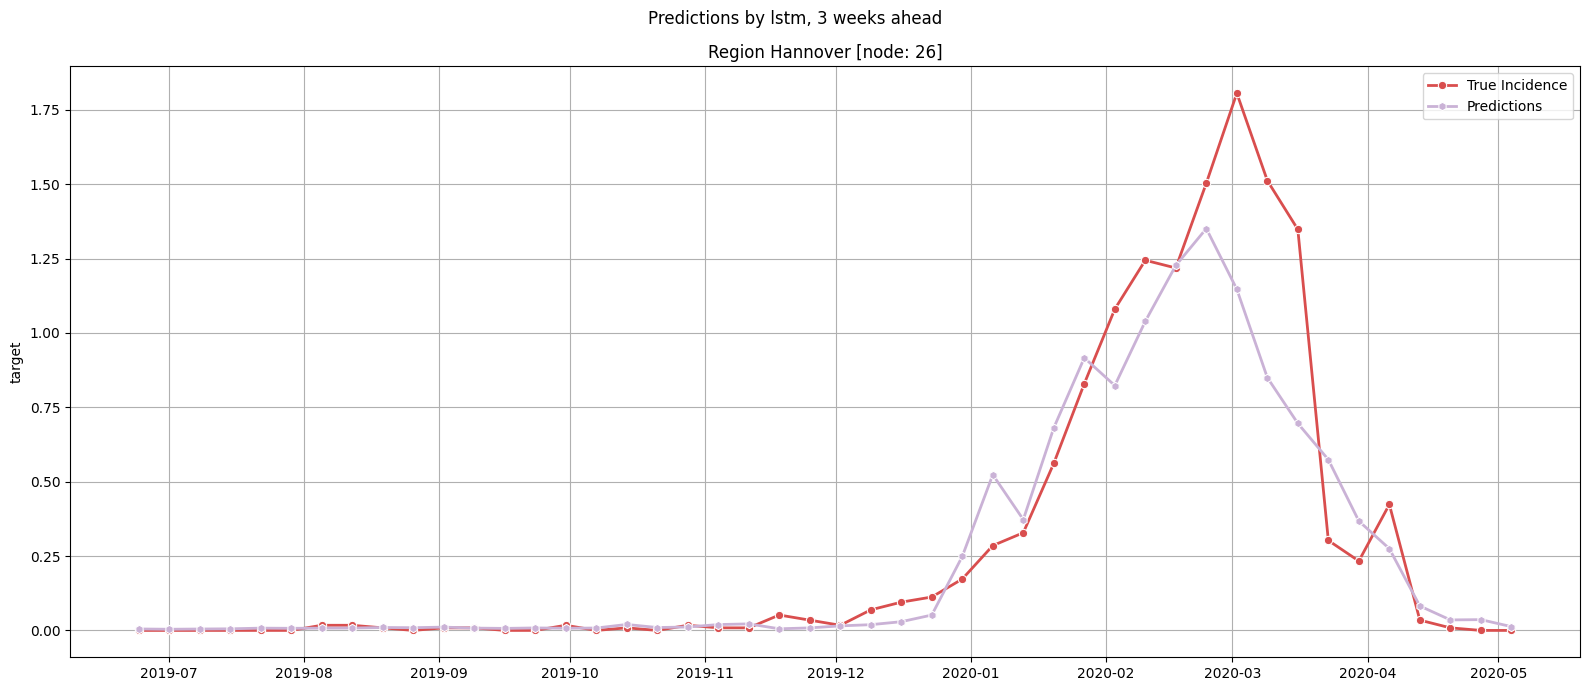

In [5]:
lstm = NodeLSTMModel(graphdataloader_id, name = 'lstm')
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train(verbose = 0, show_loss=False)
lstm.forecast('test')
lstm.show_forecasts(26)

## GNNs


==              gcn-identity_graph              ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))


Training epochs:  12%|██████████████████▊                                                                                                                                     | 31/250 [00:54<06:21,  1.74s/it]

Training epochs:  35%|████████████████████████████████████████████████████▉                                                                                                   | 87/250 [02:33<04:47,  1.76s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.5584


Forecasting test: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 651.25it/s]


...

Training epochs:  28%|███████████████████████████████████████████▏                                                                                                            | 71/250 [03:47<09:32,  3.20s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4600


Forecasting test: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 576.57it/s]

Test loss: 0.7374


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

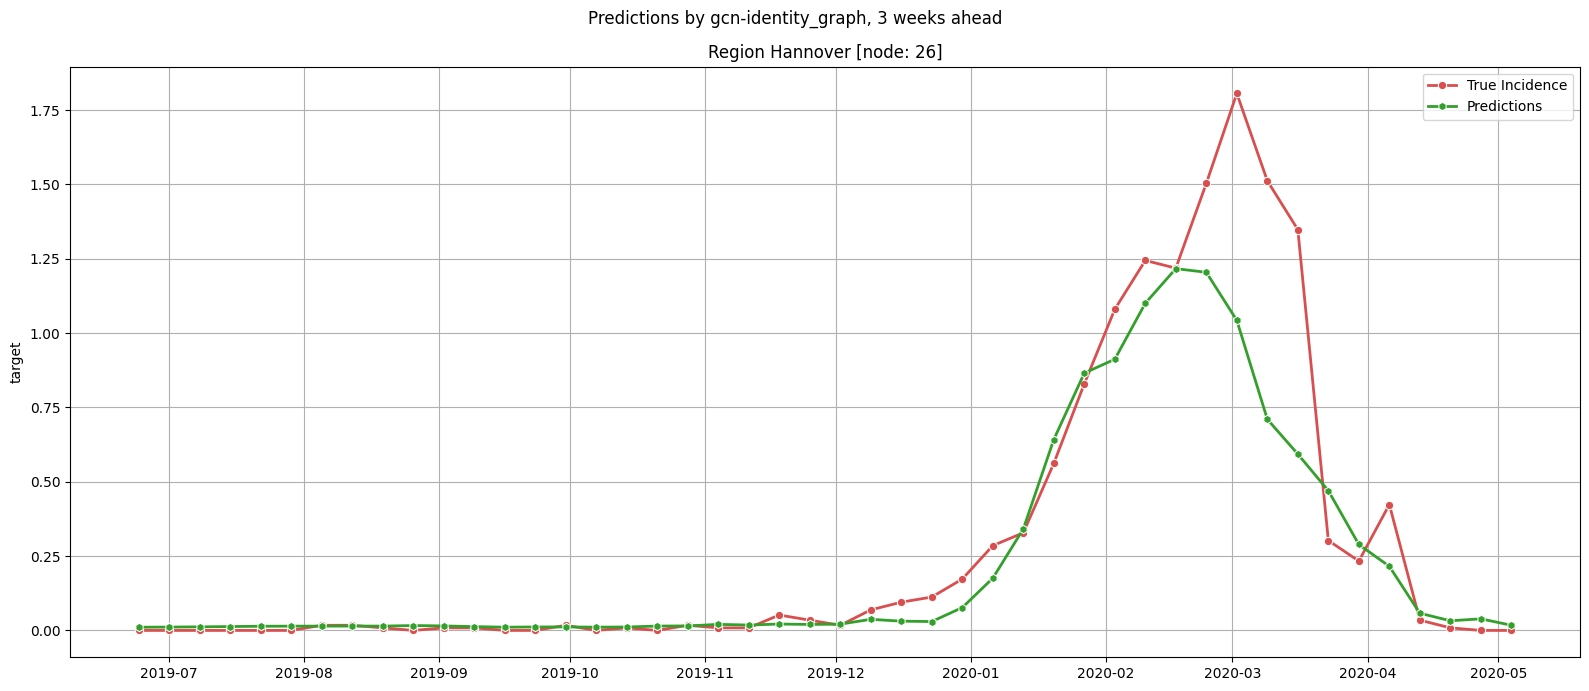

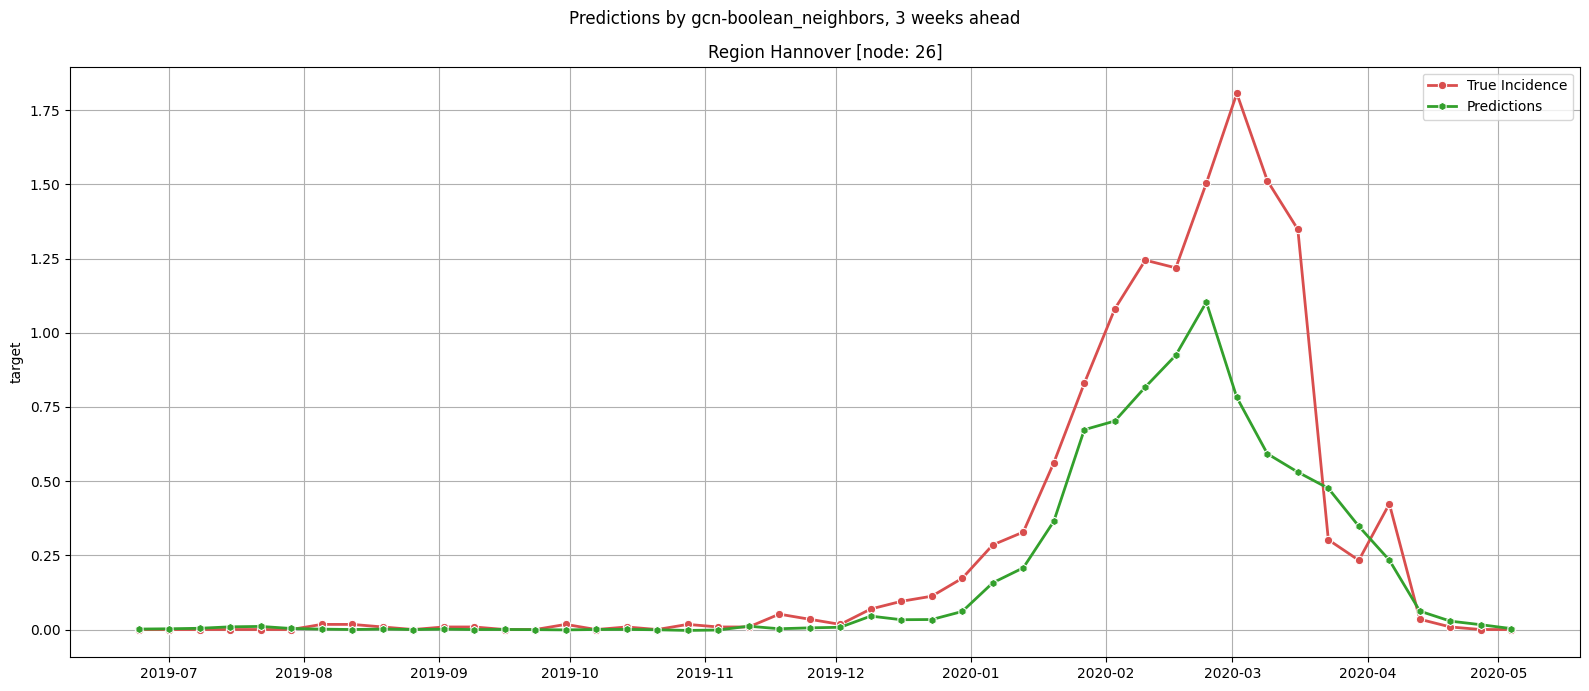

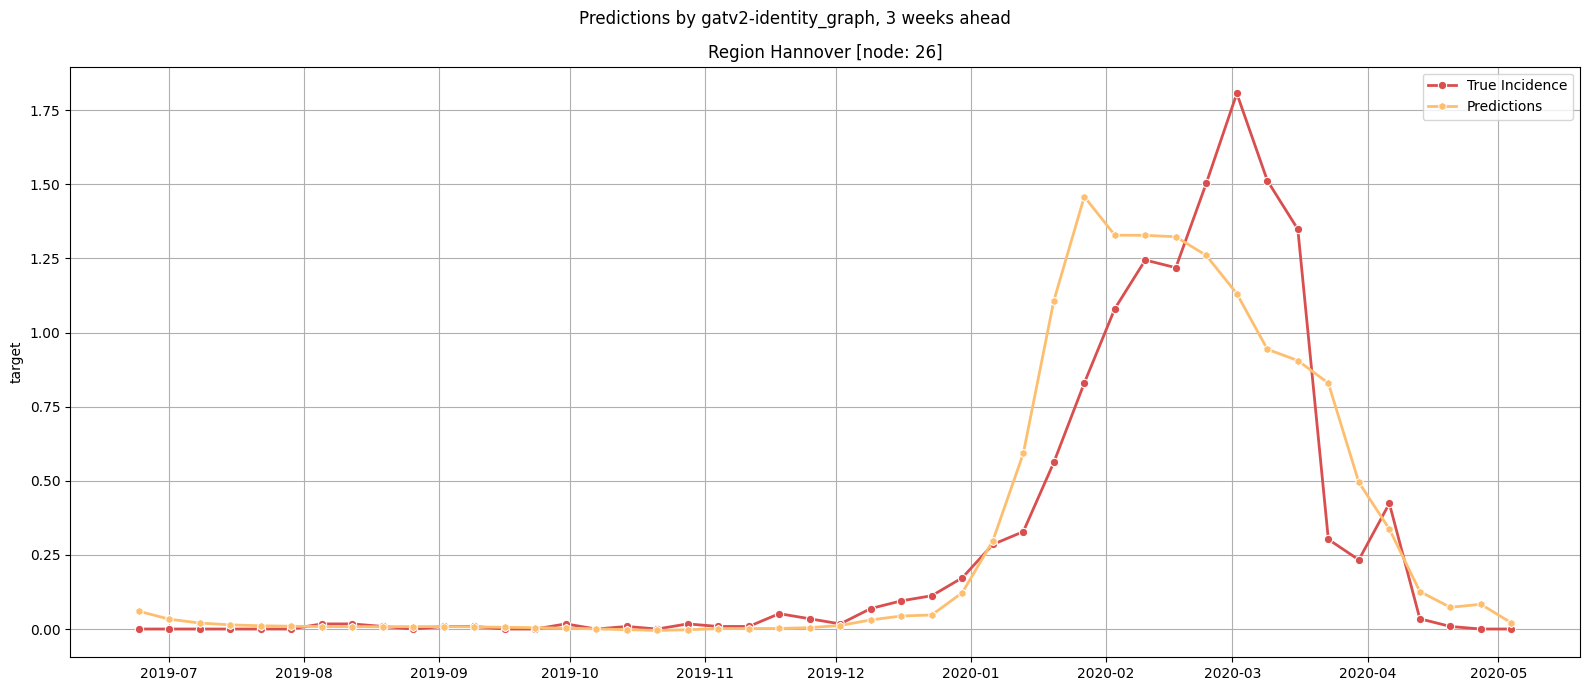

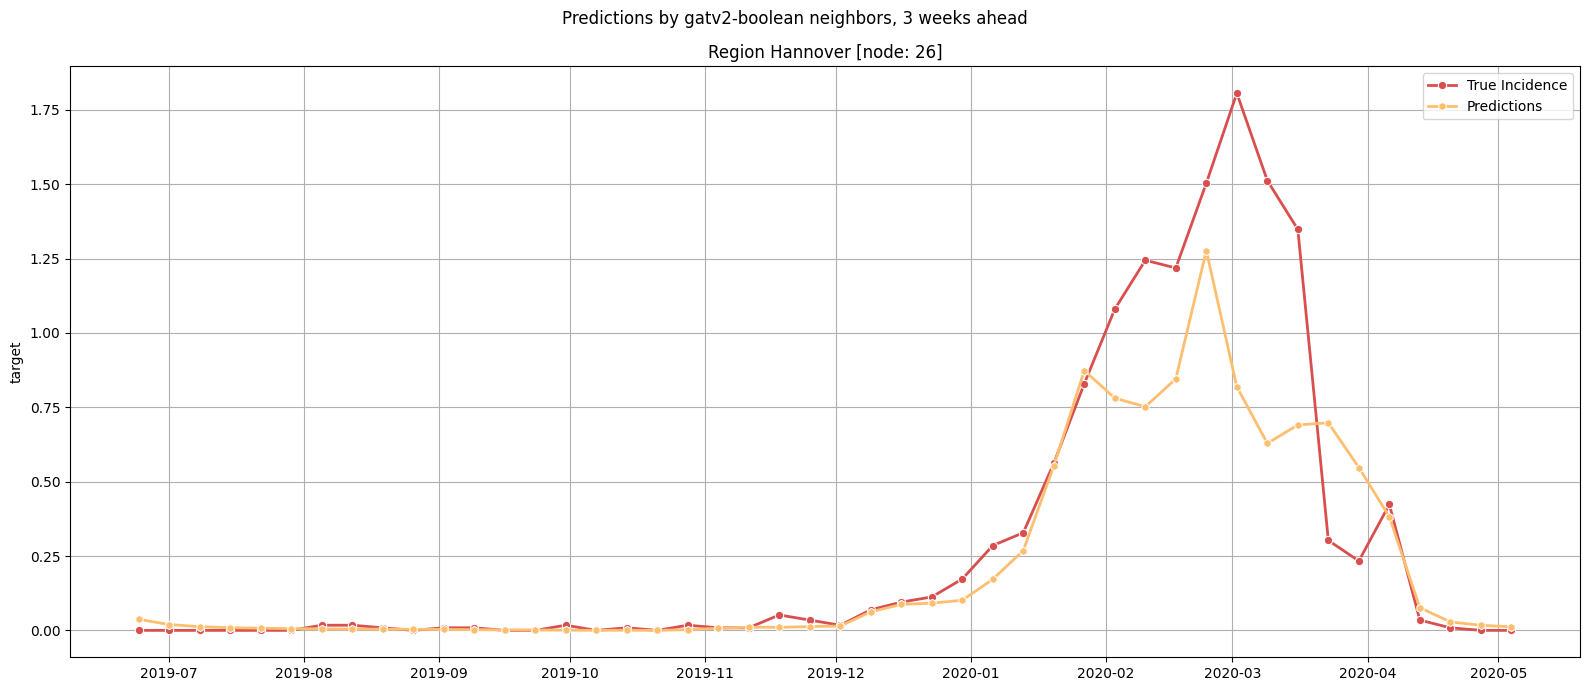

In [6]:
spatial_model1 = SpatialGNNModel(graphdataloader_id, name = 'gcn-identity_graph')
spatial_model1.set_model_hparams()
spatial_model1.set_global_hparams(**global_hparams)
spatial_model1.train(verbose = 0, show_loss=False)
spatial_model1.forecast('test')
spatial_model1.show_forecasts(26)

spatial_model2 = SpatialGNNModel(graphdataloader_bn, name = 'gcn-boolean_neighbors')
spatial_model2.set_model_hparams()
spatial_model2.set_global_hparams(**global_hparams)
spatial_model2.train(verbose = 0, show_loss=False)
spatial_model2.forecast('test')
spatial_model2.show_forecasts(26)


spatiotemporal_model1 = GATv2Model(graphdataloader_id, name = 'gatv2-identity_graph')
spatiotemporal_model1.set_model_hparams()
spatiotemporal_model1.set_global_hparams(**global_hparams)
spatiotemporal_model1.train(verbose = 0, show_loss=False)
spatiotemporal_model1.forecast('test')
spatiotemporal_model1.show_forecasts(26)

spatiotemporal_model2 = GATv2Model(graphdataloader_bn, name = 'gatv2-boolean neighbors')
spatiotemporal_model2.set_model_hparams()
spatiotemporal_model2.set_global_hparams(**global_hparams)
spatiotemporal_model2.train(verbose = 0, show_loss=False)
spatiotemporal_model2.forecast('test')
spatiotemporal_model2.show_forecasts(26)


In [7]:
evaluation = Evaluator([persistence, climateology, spatial_model1, spatial_model2, lstm, spatiotemporal_model1, spatiotemporal_model2])
evaluation.add_evaluation(0, 'test')


computing metrics: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:07<00:00,  1.17s/it]


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplott

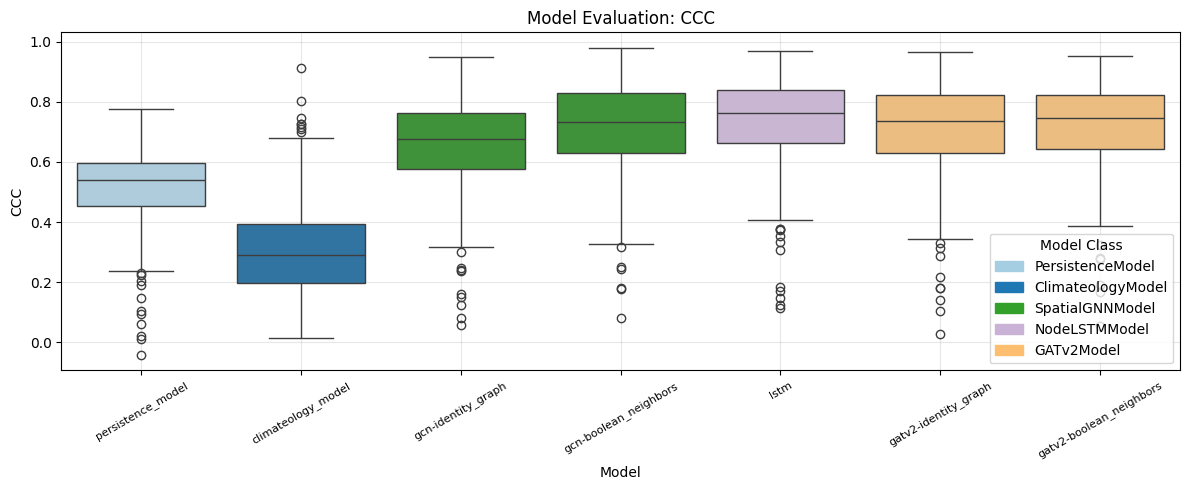

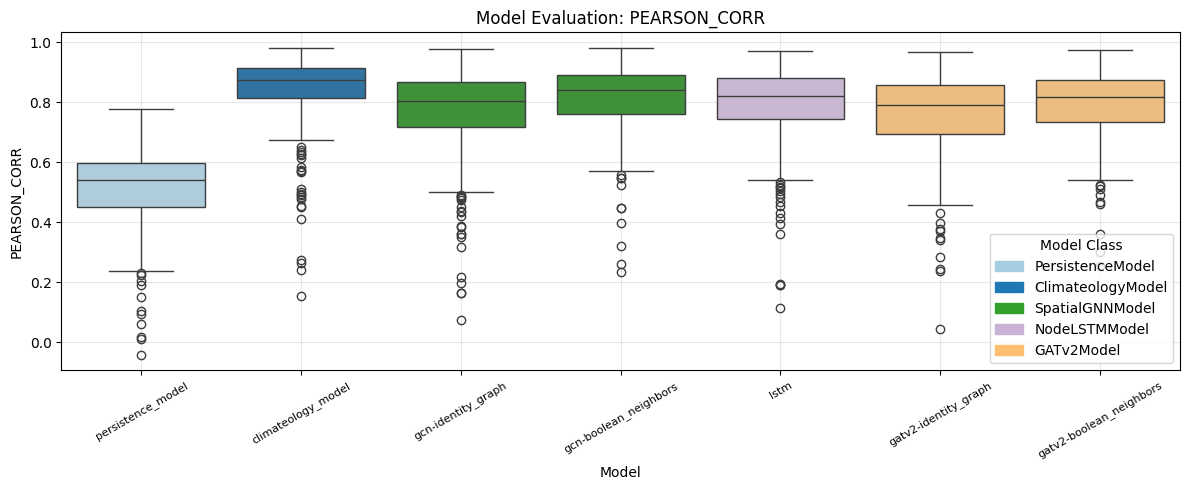

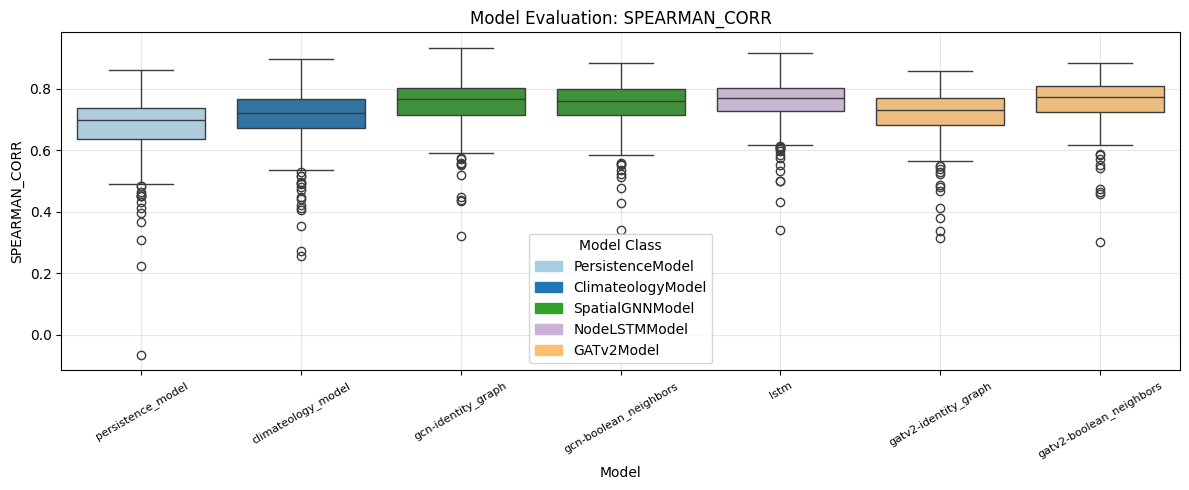

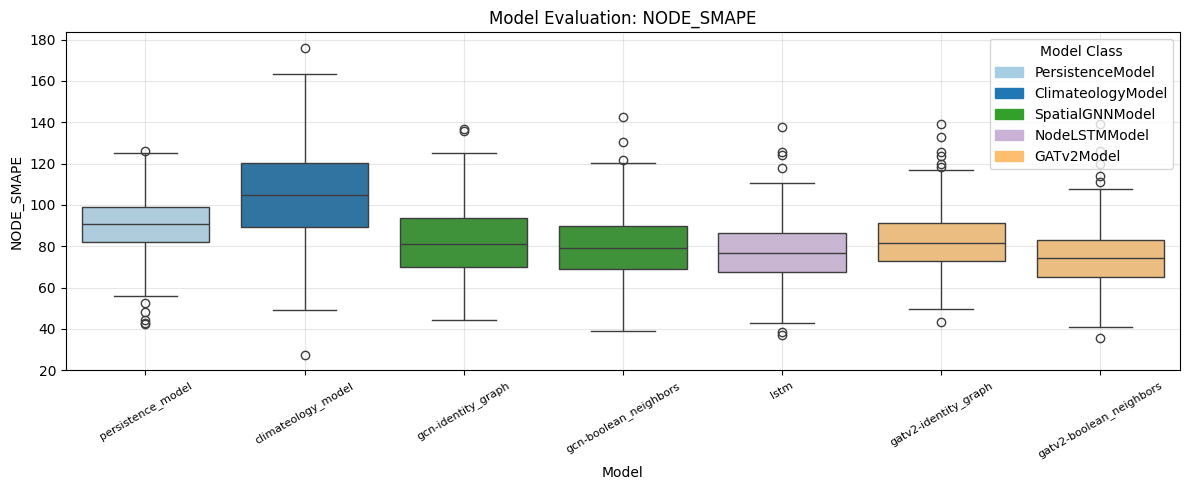

In [8]:
evaluation.plotter.plot_metric('ccc', horizon = 'horizon_0', plot_type='box')
evaluation.plotter.plot_metric('pearson_corr', horizon = 'horizon_0', plot_type='box')
evaluation.plotter.plot_metric('spearman_corr', horizon = 'horizon_0', plot_type='box')
evaluation.plotter.plot_metric('node_smape', horizon = 'horizon_0', plot_type='box')